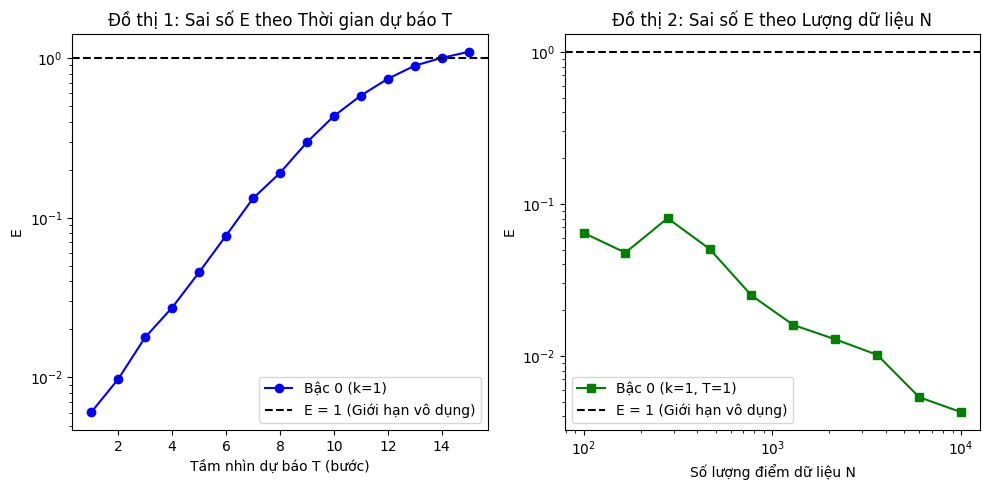

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import sys
import os
sys.path.append(os.path.abspath(".."))
from core_ntsa.predicting import predict_zeroth_order, predict_first_order
from core_ntsa.generators import simulate_henon

if __name__ == "__main__":
    # Tạo chuỗi dữ liệu gốc từ bản đồ Henon.
    data = simulate_henon(n_iterations=12000)
    
    # Lấy tọa độ x làm chuỗi thời gian 1D để thử nghiệm.
    ts = data[0, :]
    
    # Thiết lập tham số không gian pha cơ bản cho hệ Henon.
    m_dim = 2
    tau_delay = 1
    
    # ---------------------------------------------------------
    # THỰC NGHIỆM 1: Đánh giá sai số theo thời gian dự báo (T)
    # ---------------------------------------------------------
    t_values = np.arange(1, 16)
    errors_vs_t = []
    
    # Giới hạn chiều dài tín hiệu để chạy thực nghiệm đầu tiên.
    signal_exp1 = ts[:5000]
    
    for t_step in t_values:
        # Gọi hàm lõi để tính sai số ở mỗi bước dự báo tương lai.
        error, _, _ = predict_zeroth_order(
            signal=signal_exp1, m=m_dim, tau=tau_delay, horizon=t_step, train_ratio=0.8
        )
        errors_vs_t.append(error)

    # ---------------------------------------------------------
    # THỰC NGHIỆM 2: Đánh giá sai số theo lượng dữ liệu (N)
    # ---------------------------------------------------------
    n_values = np.logspace(2, 4, num=10, dtype=int)
    errors_vs_n = []
    
    # Cố định tầm nhìn dự báo là 1 bước để kiểm tra tác động của lượng dữ liệu.
    fixed_t = 1
    
    for n_points in n_values:
        # Cắt tín hiệu theo độ dài N tăng dần.
        signal_exp2 = ts[:n_points]
        error, _, _ = predict_zeroth_order(
            signal=signal_exp2, m=m_dim, tau=tau_delay, horizon=fixed_t, train_ratio=0.8
        )
        errors_vs_n.append(error)

    # ---------------------------------------------------------
    # TRỰC QUAN HÓA KẾT QUẢ
    # ---------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # Vẽ đồ thị 1: Sai số tăng theo hàm mũ khi T tăng.
    axes[0].plot(t_values, errors_vs_t, 'o-', color='blue', label='Bậc 0 (k=1)')
    axes[0].axhline(y=1.0, color='black', linestyle='--', label='E = 1 (Giới hạn vô dụng)')
    axes[0].set_yscale('log')
    axes[0].set_title("Đồ thị 1: Sai số E theo Thời gian dự báo T")
    axes[0].set_xlabel("Tầm nhìn dự báo T (bước)")
    axes[0].set_ylabel("E")
    axes[0].legend()

    # Vẽ đồ thị 2: Sai số giảm theo hàm lũy thừa khi N tăng.
    axes[1].plot(n_values, errors_vs_n, 's-', color='green', label='Bậc 0 (k=1, T=1)')
    axes[1].axhline(y=1.0, color='black', linestyle='--', label='E = 1 (Giới hạn vô dụng)')
    axes[1].set_xscale('log')
    axes[1].set_yscale('log')
    axes[1].set_title("Đồ thị 2: Sai số E theo Lượng dữ liệu N")
    axes[1].set_xlabel("Số lượng điểm dữ liệu N")
    axes[1].set_ylabel("E")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

Đang tạo dữ liệu Henon...
Đang chạy Thực nghiệm 1: Thay đổi m...
Đang chạy Thực nghiệm 2: Thay đổi tau...


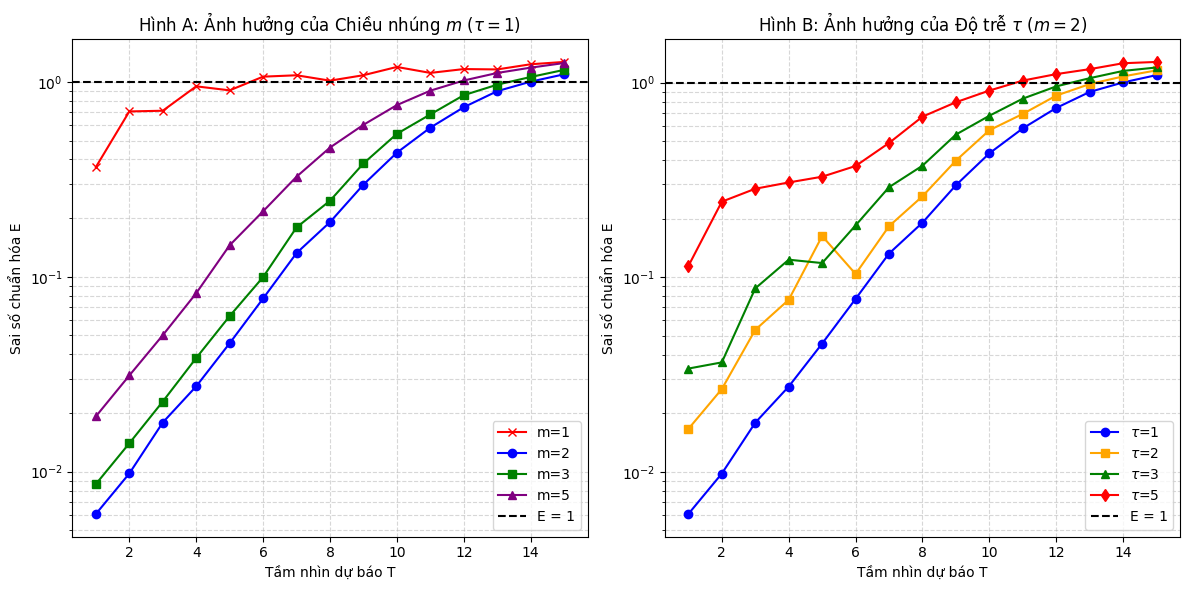

Hoàn thành!


In [10]:
import numpy as np
import matplotlib.pyplot as plt

if __name__ == "__main__":
    # 1. Khởi tạo dữ liệu (Giả định các hàm đã được định nghĩa ở trên)
    print("Đang tạo dữ liệu Henon...")
    data = simulate_henon(n_iterations=8000)
    ts = data[0, :5000]  # Cắt 5000 điểm để chạy nhanh thực nghiệm
    
    t_values = np.arange(1, 16) # Tầm nhìn dự báo T từ 1 đến 15
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    # =========================================================
    # ĐỒ THỊ 1: Thay đổi số chiều nhúng m (Cố định tau = 1)
    # =========================================================
    print("Đang chạy Thực nghiệm 1: Thay đổi m...")
    fixed_tau = 1
    m_list = [1, 2, 3, 5]
    colors_m = ['red', 'blue', 'green', 'purple']
    markers_m = ['x', 'o', 's', '^']
    
    for m, color, marker in zip(m_list, colors_m, markers_m):
        errors = []
        for t in t_values:
            err, _, _ = predict_zeroth_order(ts, m=m, tau=fixed_tau, horizon=t)
            errors.append(err)
        axes[0].plot(t_values, errors, marker=marker, linestyle='-', color=color, label=f'm={m}')
        
    axes[0].axhline(y=1.0, color='black', linestyle='--', label='E = 1')
    axes[0].set_yscale('log')
    axes[0].set_title(r"Hình A: Ảnh hưởng của Chiều nhúng $m$ ($\tau=1$)")
    axes[0].set_xlabel("Tầm nhìn dự báo T")
    axes[0].set_ylabel("Sai số chuẩn hóa E")
    axes[0].grid(True, which="both", ls="--", alpha=0.5)
    axes[0].legend()

    # =========================================================
    # ĐỒ THỊ 2: Thay đổi độ trễ tau (Cố định m = 2)
    # =========================================================
    print("Đang chạy Thực nghiệm 2: Thay đổi tau...")
    fixed_m = 2
    tau_list = [1, 2, 3, 5]
    colors_tau = ['blue', 'orange', 'green', 'red']
    markers_tau = ['o', 's', '^', 'd']
    
    for tau, color, marker in zip(tau_list, colors_tau, markers_tau):
        errors = []
        for t in t_values:
            err, _, _ = predict_zeroth_order(ts, m=fixed_m, tau=tau, horizon=t)
            errors.append(err)
        axes[1].plot(t_values, errors, marker=marker, linestyle='-', color=color, label=rf'$\tau$={tau}')
        
    axes[1].axhline(y=1.0, color='black', linestyle='--', label='E = 1')
    axes[1].set_yscale('log')
    axes[1].set_title(r"Hình B: Ảnh hưởng của Độ trễ $\tau$ ($m=2$)")
    axes[1].set_xlabel("Tầm nhìn dự báo T")
    axes[1].set_ylabel("Sai số chuẩn hóa E")
    axes[1].grid(True, which="both", ls="--", alpha=0.5)
    axes[1].legend()

    plt.tight_layout()
    plt.show()
    print("Hoàn thành!")

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import sys
import os
sys.path.append(os.path.abspath(".."))
from core_ntsa.predicting import predict_zeroth_order, predict_first_order
from core_ntsa.generators import simulate_henon

Đang chạy Thực nghiệm 1: Khả năng dự báo ngắn hạn...
Đang chạy Thực nghiệm 2: Đánh giá tính tất định theo độ dài chuỗi...


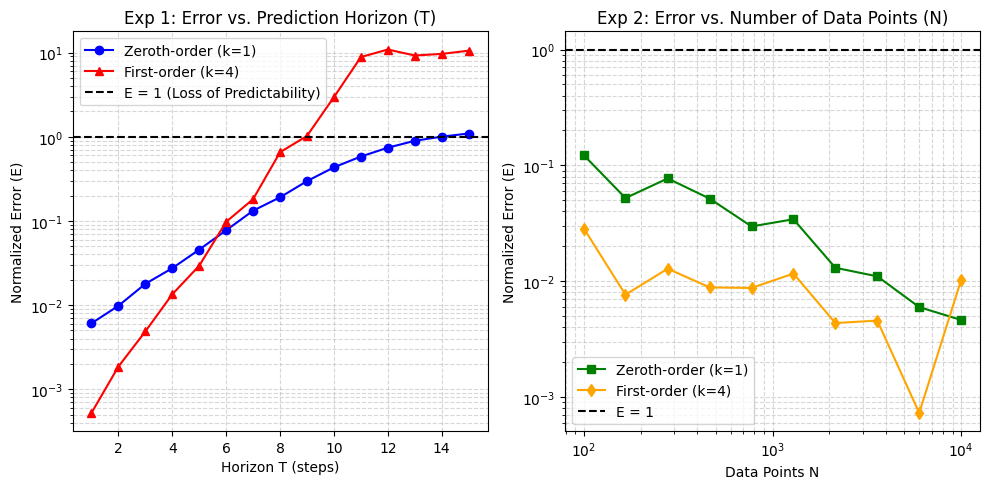

In [3]:
if __name__ == "__main__":
    # Tạo chuỗi dữ liệu gốc từ bản đồ Henon.
    data = simulate_henon(n_iterations=12000)
    
    # Lấy tọa độ x làm chuỗi thời gian 1D để thử nghiệm.
    ts = data[0, :]
    
    # Thiết lập tham số không gian pha cơ bản cho hệ Henon.
    m_dim = 2
    tau_delay = 1
    k_neighbors = 4
    
    # LƯU Ý CHIẾN LƯỢC: Vì Henon là hệ rời rạc (discrete map), không có tính 
    # quán tính lấy mẫu thừa như tín hiệu PPG liên tục, ta cấu hình cửa sổ Theiler rất nhỏ.
    henon_theiler_window = 1 
    
    # ---------------------------------------------------------
    # THỰC NGHIỆM 1: Đánh giá sai số E theo thời gian dự báo (T)
    # ---------------------------------------------------------
    print("Đang chạy Thực nghiệm 1: Khả năng dự báo ngắn hạn...")
    t_values = np.arange(1, 16)
    errors_vs_t_0 = []
    errors_vs_t_1 = []
    
    # Giới hạn chiều dài tín hiệu để chạy thực nghiệm đầu tiên.
    signal_exp1 = ts[:5000]
    
    for t_step in t_values:
        # Mô hình xấp xỉ bậc 0
        error_0, _, _ = predict_zeroth_order(
            signal=signal_exp1, m=m_dim, tau=tau_delay, horizon=t_step, train_ratio=0.8
        )
        errors_vs_t_0.append(error_0)
        
        # Mô hình xấp xỉ tuyến tính bậc 1 (Đã thêm Theiler Window)
        error_1, _, _ = predict_first_order(
            signal=signal_exp1, m=m_dim, tau=tau_delay, horizon=t_step, 
            k=k_neighbors, train_ratio=0.8, theiler_window=henon_theiler_window
        )
        errors_vs_t_1.append(error_1)

    # ---------------------------------------------------------
    # THỰC NGHIỆM 2: Đánh giá sai số E theo lượng dữ liệu (N)
    # ---------------------------------------------------------
    print("Đang chạy Thực nghiệm 2: Đánh giá tính tất định theo độ dài chuỗi...")
    n_values = np.logspace(2, 4, num=10, dtype=int)
    errors_vs_n_0 = []
    errors_vs_n_1 = []
    
    # Cố định tầm nhìn dự báo là 1 bước để kiểm tra tác động của lượng dữ liệu.
    fixed_t = 1
    
    for n_points in n_values:
        signal_exp2 = ts[:n_points]
        
        # Mô hình xấp xỉ bậc 0
        error_0, _, _ = predict_zeroth_order(
            signal=signal_exp2, m=m_dim, tau=tau_delay, horizon=fixed_t, train_ratio=0.7
        )
        errors_vs_n_0.append(error_0)
        
        # Mô hình xấp xỉ tuyến tính bậc 1 (Đã thêm Theiler Window)
        error_1, _, _ = predict_first_order(
            signal=signal_exp2, m=m_dim, tau=tau_delay, horizon=fixed_t, 
            k=k_neighbors, train_ratio=0.7, theiler_window=henon_theiler_window
        )
        errors_vs_n_1.append(error_1)

    # ---------------------------------------------------------
    # TRỰC QUAN HÓA KẾT QUẢ
    # ---------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # Đồ thị 1: Sự bùng nổ hàm mũ (Mất khả năng dự báo dài hạn)
    axes[0].plot(t_values, errors_vs_t_0, 'o-', color='blue', label='Zeroth-order (k=1)')
    axes[0].plot(t_values, errors_vs_t_1, '^-', color='red', label=f'First-order (k={k_neighbors})')
    axes[0].axhline(y=1.0, color='black', linestyle='--', label='E = 1 (Loss of Predictability)')
    axes[0].set_yscale('log')
    axes[0].set_title("Exp 1: Error vs. Prediction Horizon (T)")
    axes[0].set_xlabel("Horizon T (steps)")
    axes[0].set_ylabel("Normalized Error (E)")
    axes[0].grid(True, which="both", ls="--", alpha=0.5)
    axes[0].legend()

    # Đồ thị 2: Đặc trưng Tất định (Sai số giảm khi bão hòa không gian pha)
    axes[1].plot(n_values, errors_vs_n_0, 's-', color='green', label='Zeroth-order (k=1)')
    axes[1].plot(n_values, errors_vs_n_1, 'd-', color='orange', label=f'First-order (k={k_neighbors})')
    axes[1].axhline(y=1.0, color='black', linestyle='--', label='E = 1')
    axes[1].set_xscale('log')
    axes[1].set_yscale('log')
    axes[1].set_title("Exp 2: Error vs. Number of Data Points (N)")
    axes[1].set_xlabel("Data Points N")
    axes[1].set_ylabel("Normalized Error (E)")
    axes[1].grid(True, which="both", ls="--", alpha=0.5)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
import sys
import os
sys.path.append(os.path.abspath(".."))
from core_ntsa.generators import simulate_lorenz, simulate_henon
from core_ntsa.noise_tools import add_white_noise, add_colored_noise
from core_ntsa.metrics import calculate_wolf_lle

lorenz_data = simulate_lorenz(t_span=100.0, dt=0.01)
clean_x = lorenz_data[0]

x_white_noise = add_white_noise(clean_x, snr_db=40.0)
x_clored_noise = add_colored_noise(clean_x, color='pink', snr_db=30.0)

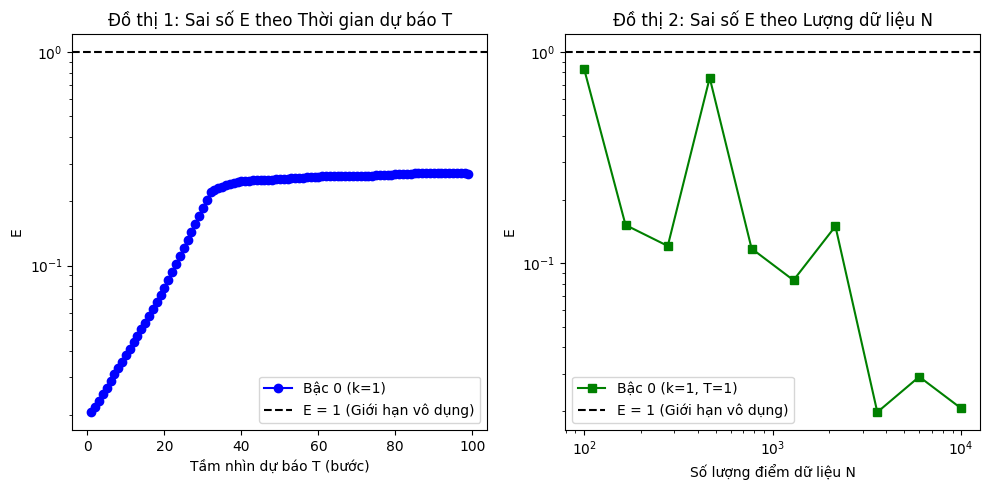

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import sys
import os
sys.path.append(os.path.abspath(".."))
from core_ntsa.predicting import predict_zeroth_order, predict_first_order
from core_ntsa.generators import simulate_henon

if __name__ == "__main__":
    
    # Thiết lập tham số không gian pha cơ bản cho hệ Henon.
    m_dim = 3
    tau_delay = 16
    
    # ---------------------------------------------------------
    # THỰC NGHIỆM 1: Đánh giá sai số theo thời gian dự báo (T)
    # ---------------------------------------------------------
    t_values = np.arange(1, 100)
    errors_vs_t = []
    
    
    for t_step in t_values:
        # Gọi hàm lõi để tính sai số ở mỗi bước dự báo tương lai.
        error, _, _ = predict_zeroth_order(
            signal=clean_x, m=m_dim, tau=tau_delay, horizon=t_step, train_ratio=0.8
        )
        errors_vs_t.append(error)

    # ---------------------------------------------------------
    # THỰC NGHIỆM 2: Đánh giá sai số theo lượng dữ liệu (N)
    # ---------------------------------------------------------
    n_values = np.logspace(2, 4, num=10, dtype=int)
    errors_vs_n = []
    
    # Cố định tầm nhìn dự báo là 1 bước để kiểm tra tác động của lượng dữ liệu.
    fixed_t = 1
    
    for n_points in n_values:
        # Cắt tín hiệu theo độ dài N tăng dần.
        signal_exp2 = clean_x[:n_points]
        error, _, _ = predict_zeroth_order(
            signal=signal_exp2, m=m_dim, tau=tau_delay, horizon=fixed_t, train_ratio=0.8
        )
        errors_vs_n.append(error)

    # ---------------------------------------------------------
    # TRỰC QUAN HÓA KẾT QUẢ
    # ---------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # Vẽ đồ thị 1: Sai số tăng theo hàm mũ khi T tăng.
    axes[0].plot(t_values, errors_vs_t, 'o-', color='blue', label='Bậc 0 (k=1)')
    axes[0].axhline(y=1.0, color='black', linestyle='--', label='E = 1 (Giới hạn vô dụng)')
    axes[0].set_yscale('log')
    axes[0].set_title("Đồ thị 1: Sai số E theo Thời gian dự báo T")
    axes[0].set_xlabel("Tầm nhìn dự báo T (bước)")
    axes[0].set_ylabel("E")
    axes[0].legend()

    # Vẽ đồ thị 2: Sai số giảm theo hàm lũy thừa khi N tăng.
    axes[1].plot(n_values, errors_vs_n, 's-', color='green', label='Bậc 0 (k=1, T=1)')
    axes[1].axhline(y=1.0, color='black', linestyle='--', label='E = 1 (Giới hạn vô dụng)')
    axes[1].set_xscale('log')
    axes[1].set_yscale('log')
    axes[1].set_title("Đồ thị 2: Sai số E theo Lượng dữ liệu N")
    axes[1].set_xlabel("Số lượng điểm dữ liệu N")
    axes[1].set_ylabel("E")
    axes[1].legend()

    plt.tight_layout()
    plt.show()